Using:
ANNOS: /Users/harshsinha/Desktop/iiitbSemester/sem6/vr/project/dataset/miniProject/data/raw/train/annos
IMAGES: /Users/harshsinha/Desktop/iiitbSemester/sem6/vr/project/dataset/miniProject/data/raw/train/images

Scanning dataset...



100%|██████████| 191961/191961 [00:29<00:00, 6585.42it/s]



========== BASIC STATS ==========
Total images: 191961
Total objects: 312186
Avg objects per image: 1.626299092003063

========== CLASS DISTRIBUTION ==========
short sleeve top: 71645
trousers: 55387
shorts: 36616
long sleeve top: 36064
skirt: 30835
vest dress: 17949
short sleeve dress: 17211
vest: 16095
long sleeve outwear: 13457
long sleeve dress: 7907


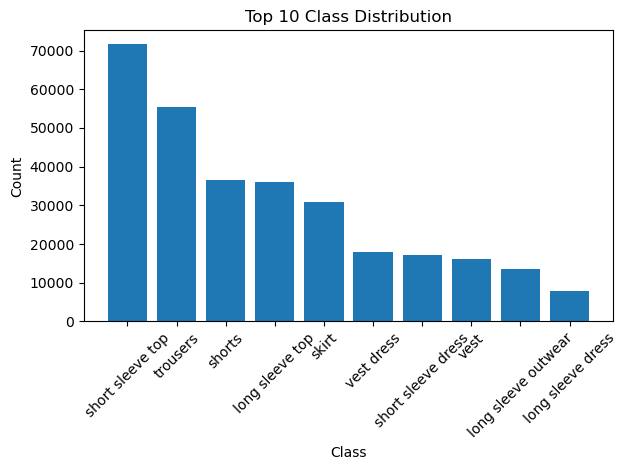

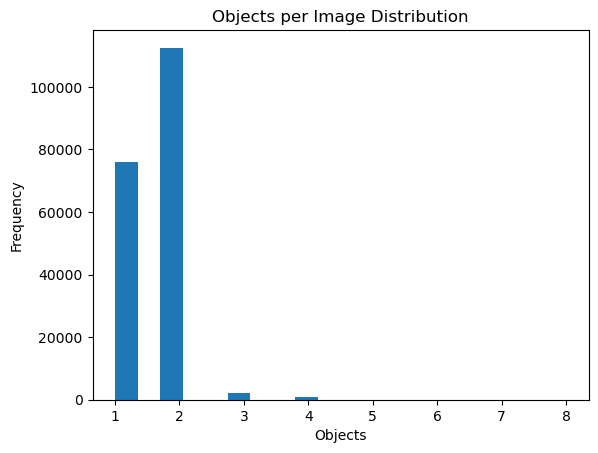


========== BBOX STATS ==========
Avg width: 293.73371238208114
Avg height: 356.9541393724875
Avg aspect ratio: 0.9209158631491338


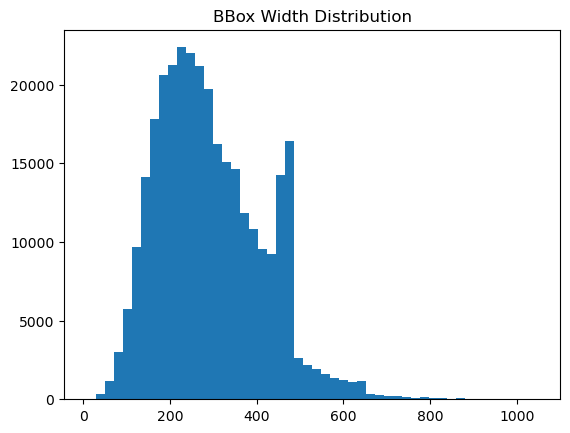

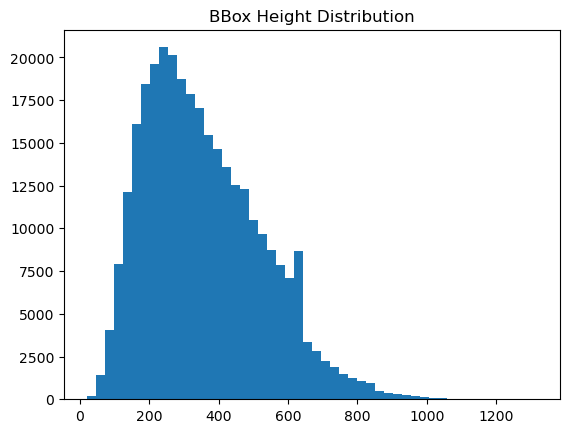

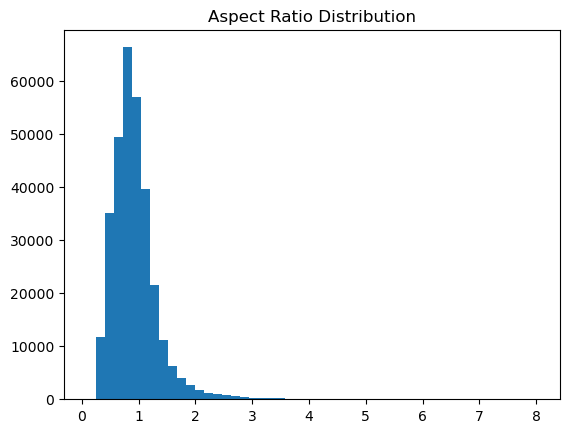


========== SEGMENTATION ==========
Objects with segmentation: 312186
Total objects: 312186
Segmentation ratio: 1.0

========== QUICK INSIGHTS ==========
Most dominant class: short sleeve top

✅ EDA Completed


In [1]:
# ============================================================
# EDA ANALYSIS FOR DEEPFASHION (RAW TRAIN)
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

# ================= PATHS =================
ROOT = os.path.abspath("..")

ANNOS = os.path.join(ROOT, "data/raw/train/annos")
IMAGES = os.path.join(ROOT, "data/raw/train/images")

print("Using:")
print("ANNOS:", ANNOS)
print("IMAGES:", IMAGES)

# ================= STORAGE =================
category_counter = Counter()
objects_per_image = []
bbox_widths = []
bbox_heights = []
aspect_ratios = []

segmentation_counts = 0
total_objects = 0

# ================= LOOP =================
print("\nScanning dataset...\n")

for file in tqdm(os.listdir(ANNOS)):

    if not file.endswith(".json"):
        continue

    path = os.path.join(ANNOS, file)

    with open(path) as f:
        data = json.load(f)

    obj_count = 0

    for k, v in data.items():

        if not k.startswith("item"):
            continue

        total_objects += 1
        obj_count += 1

        # CATEGORY
        cat = v.get("category_name", "unknown")
        category_counter[cat] += 1

        # BBOX
        if "bounding_box" in v:
            x1, y1, x2, y2 = v["bounding_box"]
            w = x2 - x1
            h = y2 - y1

            if w > 0 and h > 0:
                bbox_widths.append(w)
                bbox_heights.append(h)
                aspect_ratios.append(w / h)

        # SEGMENTATION
        segs = v.get("segmentation", [])
        if len(segs) > 0:
            segmentation_counts += 1

    objects_per_image.append(obj_count)

# ================= BASIC STATS =================
print("\n========== BASIC STATS ==========")
print("Total images:", len(objects_per_image))
print("Total objects:", total_objects)
print("Avg objects per image:", np.mean(objects_per_image))

# ================= CLASS DISTRIBUTION =================
print("\n========== CLASS DISTRIBUTION ==========")

top_classes = category_counter.most_common(10)

for cls, count in top_classes:
    print(f"{cls}: {count}")

# BAR PLOT
labels = [x[0] for x in top_classes]
values = [x[1] for x in top_classes]

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 10 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ================= OBJECTS PER IMAGE =================
plt.figure()
plt.hist(objects_per_image, bins=20)
plt.title("Objects per Image Distribution")
plt.xlabel("Objects")
plt.ylabel("Frequency")
plt.show()

# ================= BBOX ANALYSIS =================
print("\n========== BBOX STATS ==========")

print("Avg width:", np.mean(bbox_widths))
print("Avg height:", np.mean(bbox_heights))
print("Avg aspect ratio:", np.mean(aspect_ratios))

plt.figure()
plt.hist(bbox_widths, bins=50)
plt.title("BBox Width Distribution")
plt.show()

plt.figure()
plt.hist(bbox_heights, bins=50)
plt.title("BBox Height Distribution")
plt.show()

plt.figure()
plt.hist(aspect_ratios, bins=50)
plt.title("Aspect Ratio Distribution")
plt.show()

# ================= SEGMENTATION =================
print("\n========== SEGMENTATION ==========")

print("Objects with segmentation:", segmentation_counts)
print("Total objects:", total_objects)

ratio = segmentation_counts / total_objects if total_objects > 0 else 0
print("Segmentation ratio:", ratio)

# ================= INSIGHT PRINT =================
print("\n========== QUICK INSIGHTS ==========")

if ratio < 0.5:
    print("⚠️ Many objects do NOT have segmentation → model struggles")

if np.mean(objects_per_image) > 5:
    print("⚠️ Many objects per image → crowded scenes")

if len(top_classes) > 0:
    print("Most dominant class:", top_classes[0][0])

print("\n✅ EDA Completed")